In [1]:
# ============================================================
# COMPOSIÇÃO TEMPORAL EVI 
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

print("✓ Bibliotecas carregadas")

✓ Bibliotecas carregadas


In [2]:
# ============================================================
# 2. Pasta dos produtos EVI
# ============================================================

pasta_evi = Path(
    r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao"
) / "data" / "processed" / "indices" / "evi"

arquivos_evi = sorted(
    pasta_evi.glob("evi_2025*.tif")
)

print("✓ Pasta localizada")
print(f"✓ Arquivos EVI encontrados: {len(arquivos_evi)}")

for arquivo in arquivos_evi:
    print(f"  - {arquivo.name}")

✓ Pasta localizada
✓ Arquivos EVI encontrados: 10
  - evi_20240109.tif
  - evi_20240314.tif
  - evi_20240428.tif
  - evi_20240513.tif
  - evi_20240607.tif
  - evi_20240722.tif
  - evi_20240821.tif
  - evi_20240930.tif
  - evi_20241005.tif
  - evi_20241119.tif


In [3]:
# ============================================================
# 3. Validação dos arquivos EVI
# ============================================================

print("=" * 70)
print("VALIDAÇÃO DOS ARQUIVOS EVI")
print("=" * 70)

for arquivo in arquivos_evi:

    with rasterio.open(arquivo) as src:

        dados = src.read(1)

        pixels_validos = np.count_nonzero(
            np.isfinite(dados)
        )

        pixels_nodata = np.count_nonzero(
            ~np.isfinite(dados)
        )

        print(f"\nArquivo: {arquivo.name}")
        print(f"  CRS: {src.crs}")
        print(f"  Dimensões: {src.height} x {src.width}")
        print(f"  Resolução: {src.res}")
        print(f"  NoData: {src.nodata}")
        print(f"  Pixels válidos: {pixels_validos}")
        print(f"  Pixels NoData: {pixels_nodata}")

        if pixels_validos > 0:
            valores = dados[np.isfinite(dados)]

            print(f"  Mínimo: {valores.min():.4f}")
            print(f"  Máximo: {valores.max():.4f}")
            print(f"  Média: {valores.mean():.4f}")

        else:
            print("  ⚠️ Nenhum pixel válido encontrado!")

VALIDAÇÃO DOS ARQUIVOS EVI

Arquivo: evi_20240109.tif
  CRS: EPSG:32722
  Dimensões: 222 x 140
  Resolução: (10.0, 10.0)
  NoData: 0.0
  Pixels válidos: 31080
  Pixels NoData: 0
  Mínimo: 0.0000
  Máximo: 0.8807
  Média: 0.2933

Arquivo: evi_20240314.tif
  CRS: EPSG:32723
  Dimensões: 220 x 141
  Resolução: (10.0, 10.0)
  NoData: 0.0
  Pixels válidos: 31020
  Pixels NoData: 0
  Mínimo: 0.0000
  Máximo: 1.7198
  Média: 0.2197

Arquivo: evi_20240428.tif
  CRS: EPSG:32722
  Dimensões: 222 x 140
  Resolução: (10.0, 10.0)
  NoData: 0.0
  Pixels válidos: 31080
  Pixels NoData: 0
  Mínimo: 0.0000
  Máximo: 0.7195
  Média: 0.2008

Arquivo: evi_20240513.tif
  CRS: EPSG:32722
  Dimensões: 222 x 140
  Resolução: (10.0, 10.0)
  NoData: 0.0
  Pixels válidos: 31080
  Pixels NoData: 0
  Mínimo: 0.0000
  Máximo: 0.7360
  Média: 0.2099

Arquivo: evi_20240607.tif
  CRS: EPSG:32722
  Dimensões: 222 x 140
  Resolução: (10.0, 10.0)
  NoData: 0.0
  Pixels válidos: 31080
  Pixels NoData: 0
  Mínimo: 0.0000
 

In [4]:
# ============================================================
# DIAGNÓSTICO — DIMENSÕES DOS RASTERS EVI
# ============================================================

print("=" * 70)
print("VERIFICAÇÃO DOS RASTERS EVI")
print("=" * 70)

arquivos_evi = sorted(
    pasta_evi.glob("evi_2025*.tif")
)

for arquivo in arquivos_evi:

    with rasterio.open(arquivo) as src:

        print(
            f"\n{arquivo.name}"
        )

        print(
            f"  ✓ Dimensões: "
            f"{src.height} x {src.width}"
        )

        print(
            f"  ✓ CRS: {src.crs}"
        )

        print(
            f"  ✓ Resolução: "
            f"{src.res[0]:.2f} x "
            f"{src.res[1]:.2f} m"
        )

        print(
            f"  ✓ Transform: "
            f"{src.transform}"
        )

print("\n" + "=" * 70)
print("✓ DIAGNÓSTICO CONCLUÍDO")
print("=" * 70)

VERIFICAÇÃO DOS RASTERS EVI

evi_20240109.tif
  ✓ Dimensões: 222 x 140
  ✓ CRS: EPSG:32722
  ✓ Resolução: 10.00 x 10.00 m
  ✓ Transform: | 10.00, 0.00, 852790.00|
| 0.00,-10.00, 7401030.00|
| 0.00, 0.00, 1.00|

evi_20240314.tif
  ✓ Dimensões: 220 x 141
  ✓ CRS: EPSG:32723
  ✓ Resolução: 10.00 x 10.00 m
  ✓ Transform: | 10.00, 0.00, 239820.00|
| 0.00,-10.00, 7402990.00|
| 0.00, 0.00, 1.00|

evi_20240428.tif
  ✓ Dimensões: 222 x 140
  ✓ CRS: EPSG:32722
  ✓ Resolução: 10.00 x 10.00 m
  ✓ Transform: | 10.00, 0.00, 852790.00|
| 0.00,-10.00, 7401030.00|
| 0.00, 0.00, 1.00|

evi_20240513.tif
  ✓ Dimensões: 222 x 140
  ✓ CRS: EPSG:32722
  ✓ Resolução: 10.00 x 10.00 m
  ✓ Transform: | 10.00, 0.00, 852790.00|
| 0.00,-10.00, 7401030.00|
| 0.00, 0.00, 1.00|

evi_20240607.tif
  ✓ Dimensões: 222 x 140
  ✓ CRS: EPSG:32722
  ✓ Resolução: 10.00 x 10.00 m
  ✓ Transform: | 10.00, 0.00, 852790.00|
| 0.00,-10.00, 7401030.00|
| 0.00, 0.00, 1.00|

evi_20240722.tif
  ✓ Dimensões: 222 x 140
  ✓ CRS: EPSG:32722

In [5]:
# ============================================================
# 6. Padronização espacial — todos os meses
# ============================================================

from rasterio.warp import reproject, Resampling
from pathlib import Path
import rasterio
import numpy as np
import os

print("=" * 70)
print("PADRONIZAÇÃO ESPACIAL — TODOS OS ARQUIVOS EVI")
print("=" * 70)

# ------------------------------------------------------------
# Caminho da pasta EVI
# ------------------------------------------------------------
BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
pasta_evi = BASE / "data" / "processed" / "indices" / "evi"

# ------------------------------------------------------------
# Lista dos arquivos EVI (excluir a mediana)
# ------------------------------------------------------------
arquivos_evi = sorted(
    f for f in pasta_evi.glob("evi_2025*.tif")
    if "mediana" not in f.name
)

print(f"\n✓ Arquivos encontrados: {len(arquivos_evi)}")
for arq in arquivos_evi:
    print(f"   - {arq.name}")

# ------------------------------------------------------------
# Grade de referência — primeiro arquivo da lista
# ------------------------------------------------------------
arquivo_referencia = arquivos_evi[0]

with rasterio.open(arquivo_referencia) as src:
    perfil_referencia = src.profile.copy()
    altura_referencia = src.height
    largura_referencia = src.width
    transform_referencia = src.transform
    crs_referencia = src.crs
    nodata_referencia = src.nodata

print("\n✓ Grade de referência:")
print(f"  Arquivo: {arquivo_referencia.name}")
print(f"  CRS: {crs_referencia}")
print(f"  Dimensões: {altura_referencia} x {largura_referencia}")
print(f"  Resolução: {transform_referencia.a:.2f} x {abs(transform_referencia.e):.2f} m")

# ------------------------------------------------------------
# Padronização e substituição dos arquivos
# ------------------------------------------------------------
for arquivo in arquivos_evi:

    arquivo_temporario = arquivo.with_name(arquivo.stem + "_temp.tif")

    with rasterio.open(arquivo) as src:

        # Verificar se já está na grade correta
        ja_alinhado = (
            src.height == altura_referencia
            and src.width == largura_referencia
            and src.transform == transform_referencia
            and src.crs == crs_referencia
        )

        if ja_alinhado:
            print(f"⏭ Já alinhado: {arquivo.name}")
            continue

        # Ler dados
        dados = src.read(1).astype(np.float32)

        # Substituir nodata por NaN
        if src.nodata is not None:
            dados[dados == src.nodata] = np.nan

        dados_alinhados = np.full(
            (altura_referencia, largura_referencia),
            np.nan,
            dtype=np.float32
        )

        reproject(
            source=dados,
            destination=dados_alinhados,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform_referencia,
            dst_crs=crs_referencia,
            src_nodata=np.nan,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear
        )

        perfil_saida = perfil_referencia.copy()
        perfil_saida.update(dtype="float32", count=1, nodata=np.nan)

    # --------------------------------------------------------
    # Grava arquivo temporário
    # --------------------------------------------------------
    with rasterio.open(arquivo_temporario, "w", **perfil_saida) as dst:
        dst.write(dados_alinhados, 1)

    # --------------------------------------------------------
    # Substitui o original
    # --------------------------------------------------------
    os.replace(arquivo_temporario, arquivo)

    # Estatísticas pós-alinhamento
    validos = dados_alinhados[~np.isnan(dados_alinhados)]
    print(
        f"✓ {arquivo.name}  |  "
        f"min={validos.min():.3f}  "
        f"max={validos.max():.3f}  "
        f"média={validos.mean():.3f}"
    )

# ------------------------------------------------------------
# Resumo final
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("✓ PADRONIZAÇÃO CONCLUÍDA")
print("=" * 70)
print(f"✓ Arquivos processados: {len(arquivos_evi)}")
print(f"✓ CRS de referência: {crs_referencia}")
print(f"✓ Dimensões: {altura_referencia} x {largura_referencia}")
print(f"✓ Resolução: {transform_referencia.a:.2f} x {abs(transform_referencia.e):.2f} m")
print("✓ Arquivos originais substituídos (nenhuma pasta extra)")

PADRONIZAÇÃO ESPACIAL — TODOS OS ARQUIVOS EVI

✓ Arquivos encontrados: 10
   - evi_20240109.tif
   - evi_20240314.tif
   - evi_20240428.tif
   - evi_20240513.tif
   - evi_20240607.tif
   - evi_20240722.tif
   - evi_20240821.tif
   - evi_20240930.tif
   - evi_20241005.tif
   - evi_20241119.tif

✓ Grade de referência:
  Arquivo: evi_20240109.tif
  CRS: EPSG:32722
  Dimensões: 222 x 140
  Resolução: 10.00 x 10.00 m
⏭ Já alinhado: evi_20240109.tif
✓ evi_20240314.tif  |  min=0.069  max=1.543  média=0.354
⏭ Já alinhado: evi_20240428.tif
⏭ Já alinhado: evi_20240513.tif
⏭ Já alinhado: evi_20240607.tif
⏭ Já alinhado: evi_20240722.tif
✓ evi_20240821.tif  |  min=0.060  max=0.600  média=0.356
✓ evi_20240930.tif  |  min=0.078  max=0.615  média=0.286
⏭ Já alinhado: evi_20241005.tif
⏭ Já alinhado: evi_20241119.tif

✓ PADRONIZAÇÃO CONCLUÍDA
✓ Arquivos processados: 10
✓ CRS de referência: EPSG:32722
✓ Dimensões: 222 x 140
✓ Resolução: 10.00 x 10.00 m
✓ Arquivos originais substituídos (nenhuma pasta ext

In [6]:
# ============================================================
# 7. Composição temporal EVI — Mediana de 2025
# ============================================================

print("=" * 70)
print("COMPOSIÇÃO TEMPORAL EVI — 2025")
print("=" * 70)

# Lista dos arquivos EVI originais
arquivos_evi = sorted(
    pasta_evi.glob("evi_2025*.tif")
)

# Lista para armazenar os rasters
pilha_evi = []

# Leitura dos 12 arquivos EVI
for arquivo in arquivos_evi:

    with rasterio.open(arquivo) as src:

        dados = src.read(1).astype(np.float32)

        # NoData → NaN
        if src.nodata is not None:
            dados[~np.isfinite(dados)] = np.nan

        pilha_evi.append(dados)

# Cria a pilha temporal
pilha_evi = np.stack(
    pilha_evi,
    axis=0
)

print(f"✓ Imagens utilizadas: {pilha_evi.shape[0]}")
print(f"✓ Dimensões da pilha: {pilha_evi.shape}")

# Mediana temporal
evi_mediana_2025 = np.nanmedian(
    pilha_evi,
    axis=0
)

# Estatísticas
valores_validos = evi_mediana_2025[
    np.isfinite(evi_mediana_2025)
]

print("\n✓ Composição temporal calculada")
print(f"✓ Pixels válidos: {len(valores_validos):,}")
print(f"✓ Mínimo: {valores_validos.min():.4f}")
print(f"✓ Máximo: {valores_validos.max():.4f}")
print(f"✓ Média: {valores_validos.mean():.4f}")
print(f"✓ Mediana: {np.median(valores_validos):.4f}")
print(f"✓ Desvio-padrão: {valores_validos.std():.4f}")

COMPOSIÇÃO TEMPORAL EVI — 2024
✓ Imagens utilizadas: 10
✓ Dimensões da pilha: (10, 222, 140)

✓ Composição temporal calculada
✓ Pixels válidos: 31,080
✓ Mínimo: 0.0000
✓ Máximo: 0.6925
✓ Média: 0.2088
✓ Mediana: 0.2487
✓ Desvio-padrão: 0.1822


In [7]:
# ============================================================
# 8. Exportação da composição temporal EVI — 2025
# ============================================================

arquivo_composicao = pasta_evi / "evi_mediana_2025.tif"

perfil_composicao = perfil_referencia.copy()

perfil_composicao.update(
    dtype="float32",
    count=1,
    nodata=np.nan
)

with rasterio.open(
    arquivo_composicao,
    "w",
    **perfil_composicao
) as dst:

    dst.write(
        evi_mediana_2025.astype(np.float32),
        1
    )

print("=" * 70)
print("EXPORTAÇÃO DA COMPOSIÇÃO TEMPORAL EVI")
print("=" * 70)

print(f"✓ Arquivo criado: {arquivo_composicao.name}")
print(f"✓ CRS: {crs_referencia}")
print(f"✓ Dimensões: {altura_referencia} x {largura_referencia}")
print("✓ Resolução: 10 x 10 m")
print(f"✓ Caminho: {arquivo_composicao}")

EXPORTAÇÃO DA COMPOSIÇÃO TEMPORAL EVI
✓ Arquivo criado: evi_mediana_2024.tif
✓ CRS: EPSG:32722
✓ Dimensões: 222 x 140
✓ Resolução: 10 x 10 m
✓ Caminho: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\data\processed\indices\evi\evi_mediana_2024.tif


In [8]:
# ============================================================
# 9. Validação final da composição EVI — 2025
# ============================================================

print("=" * 70)
print("VALIDAÇÃO FINAL — COMPOSIÇÃO EVI 2025")
print("=" * 70)

with rasterio.open(arquivo_composicao) as src:

    dados_composicao = src.read(1)

    print(f"\n✓ Arquivo: {arquivo_composicao.name}")
    print(f"✓ CRS: {src.crs}")
    print(f"✓ Dimensões: {src.height} x {src.width}")
    print(f"✓ Resolução: {src.res}")
    print(f"✓ NoData: {src.nodata}")

    valores_validos = dados_composicao[
        np.isfinite(dados_composicao)
    ]

    print(f"✓ Pixels válidos: {len(valores_validos):,}")
    print(f"✓ Pixels NoData: {np.count_nonzero(~np.isfinite(dados_composicao)):,}")

    print("\nESTATÍSTICAS")
    print(f"  Mínimo: {valores_validos.min():.4f}")
    print(f"  Máximo: {valores_validos.max():.4f}")
    print(f"  Média: {valores_validos.mean():.4f}")
    print(f"  Mediana: {np.median(valores_validos):.4f}")
    print(f"  Desvio-padrão: {valores_validos.std():.4f}")

print("\n" + "=" * 70)
print("✓ VALIDAÇÃO FINAL CONCLUÍDA")
print("=" * 70)

VALIDAÇÃO FINAL — COMPOSIÇÃO EVI 2024

✓ Arquivo: evi_mediana_2024.tif
✓ CRS: EPSG:32722
✓ Dimensões: 222 x 140
✓ Resolução: (10.0, 10.0)
✓ NoData: nan
✓ Pixels válidos: 31,080
✓ Pixels NoData: 0

ESTATÍSTICAS
  Mínimo: 0.0000
  Máximo: 0.6925
  Média: 0.2088
  Mediana: 0.2487
  Desvio-padrão: 0.1822

✓ VALIDAÇÃO FINAL CONCLUÍDA


In [9]:
# ============================================================
# 10A. Carregamento da AOI da propriedade
# ============================================================

import geopandas as gpd
from pathlib import Path

pasta_raw = Path(
    r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao"
) / "data" / "raw"

arquivo_imovel = pasta_raw / "Area_do_Imovel.zip"

imovel = gpd.read_file(arquivo_imovel)

# Reprojeção para o CRS da composição EVI
imovel_evi = imovel.to_crs(crs_referencia)

# Como os dois registros possuem a mesma geometria,
# usamos apenas um deles.
aoi_evi = imovel_evi.geometry.iloc[0]

print("=" * 70)
print("AOI DA PROPRIEDADE")
print("=" * 70)

print(f"\n✓ Feições carregadas: {len(imovel)}")
print(f"✓ CRS original: {imovel.crs}")
print(f"✓ CRS da composição: {imovel_evi.crs}")
print(f"✓ Tipo de geometria: {aoi_evi.geom_type}")

print("\n" + "=" * 70)
print("✓ AOI CARREGADA E REPROJETADA")
print("=" * 70)

AOI DA PROPRIEDADE

✓ Feições carregadas: 2
✓ CRS original: EPSG:4674
✓ CRS da composição: PROJCS["WGS 84 / UTM zone 22S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32722"]]
✓ Tipo de geometria: Polygon

✓ AOI CARREGADA E REPROJETADA


EVI — min: 0.119 | max: 0.692
EVI — média: 0.337 | mediana: 0.303
EVI — p5: 0.207 | p95: 0.522
CRS: EPSG:32722
Extent: X [852790, 854190] | Y [7398810, 7401030]
Pixels nativos: 10 m


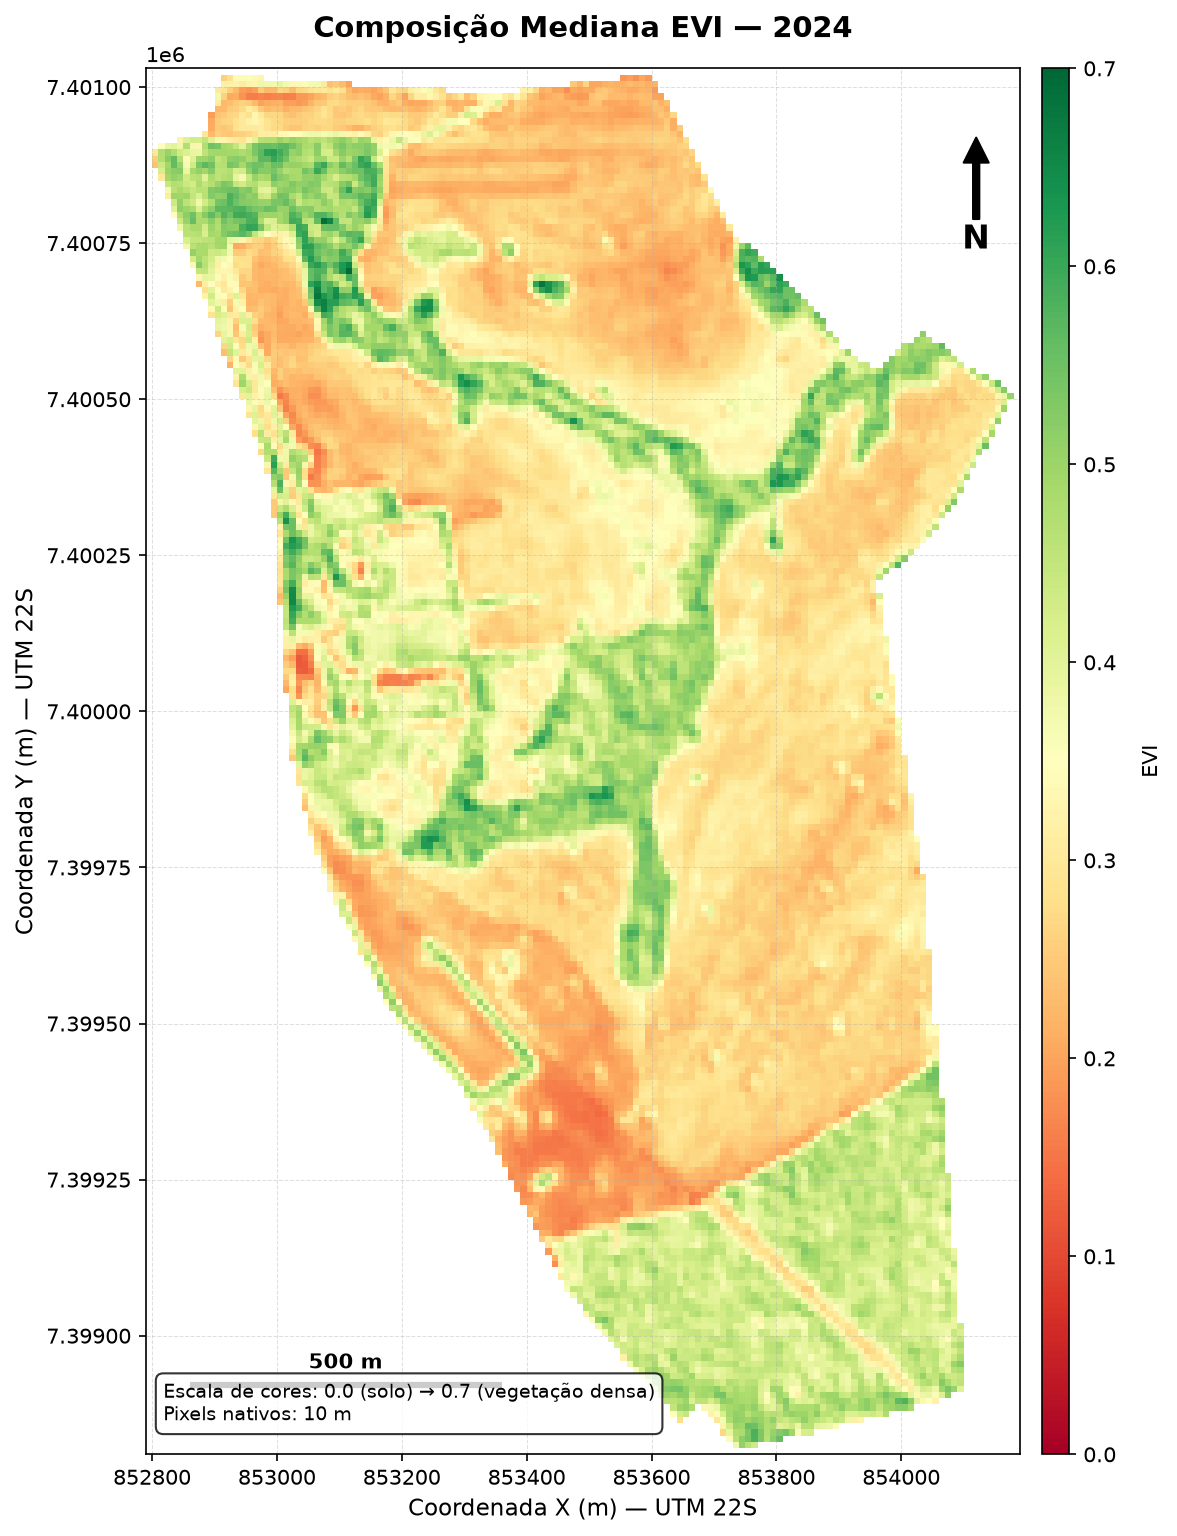

In [10]:
# ============================================================
# 10. Visualização da composição mediana EVI — 2025
#     Recortada pela AOI
# ============================================================

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import rasterio
from rasterio.mask import mask
import numpy as np

# ============================================================
# Recorte pela AOI
# ============================================================
with rasterio.open(arquivo_composicao) as src:
    evi_aoi, transform_evi = mask(
        src,
        [aoi_evi],
        crop=True,
        nodata=np.nan
    )
    evi_aoi = evi_aoi[0]
    
    # Metadados para eixos UTM
    left = transform_evi.c
    top = transform_evi.f
    nrows, ncols = evi_aoi.shape
    pixel_size_x = transform_evi.a
    pixel_size_y = transform_evi.e
    right = left + ncols * pixel_size_x
    bottom = top + nrows * pixel_size_y
    crs_src = src.crs

# ============================================================
# Diagnóstico
# ============================================================
evi_valid = evi_aoi[~np.isnan(evi_aoi)]
print(f"EVI — min: {evi_valid.min():.3f} | max: {evi_valid.max():.3f}")
print(f"EVI — média: {evi_valid.mean():.3f} | mediana: {np.median(evi_valid):.3f}")
print(f"EVI — p5: {np.percentile(evi_valid, 5):.3f} | p95: {np.percentile(evi_valid, 95):.3f}")
print(f"CRS: {crs_src}")
print(f"Extent: X [{left:.0f}, {right:.0f}] | Y [{bottom:.0f}, {top:.0f}]")
print(f"Pixels nativos: {abs(pixel_size_x):.0f} m")

# ============================================================
# Visualização
# ============================================================
fig, ax = plt.subplots(figsize=(9, 12), dpi=150)

imagem = ax.imshow(
    evi_aoi,
    cmap="RdYlGn",
    vmin=0.0,
    vmax=0.7,                    # ← AJUSTADO: equilíbrio técnico/visual
    interpolation="nearest",     # ← Mantém nitidez dos pixels
    extent=[left, right, bottom, top]
)

# ============================================================
# Colorbar ALINHADA AUTOMATICAMENTE
# ============================================================
divider = make_axes_locatable(ax)
cbar_ax = divider.append_axes("right", size="3%", pad=0.15)
cbar = fig.colorbar(imagem, cax=cbar_ax)
cbar.set_label("EVI", rotation=90, labelpad=12)

# ============================================================
# Títulos e rótulos
# ============================================================
ax.set_title("Composição Mediana EVI — 2025",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Coordenada X (m) — UTM 22S", fontsize=11)
ax.set_ylabel("Coordenada Y (m) — UTM 22S", fontsize=11)

# Norte
ax.annotate(
    "N",
    xy=(0.95, 0.95), xytext=(0.95, 0.87),
    xycoords="axes fraction", textcoords="axes fraction",
    arrowprops=dict(facecolor="black", width=3, headwidth=12),
    fontsize=16, ha="center", fontweight="bold"
)

# Escala gráfica (500 m)
escala_m = 500
x0 = left + (right - left) * 0.05
y0 = bottom + (top - bottom) * 0.05
ax.plot([x0, x0 + escala_m], [y0, y0], "k-", linewidth=3, solid_capstyle="butt")
ax.text(x0 + escala_m / 2, y0 + (top - bottom) * 0.012,
        f"{escala_m} m", ha="center", fontsize=10, fontweight="bold")

# Grid
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

# ============================================================
# Nota técnica (atualizada com vmax correto)
# ============================================================
nota = (
    "Escala de cores: 0.0 (solo) → 0.7 (vegetação densa)\n"
    f"Pixels nativos: {abs(pixel_size_x):.0f} m"
)
ax.text(0.02, 0.02, nota, transform=ax.transAxes, fontsize=9,
        verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

# ⚠️ NÃO usar tight_layout aqui — make_axes_locatable já cuida do layout
plt.show()

In [11]:
fig.savefig(
    pasta_evi / "evi_mediana_2025.png",
    dpi=300,
    bbox_inches="tight"
)

NDVI: shape (222, 140), CRS EPSG:32722
EVI:  shape (222, 140),  CRS EPSG:32722

Métrica    NDVI         EVI         
Min        0.133        0.000       
Max        0.875        0.692       
Média      0.568        0.209       
P95        0.834        0.501       

📊 Correlação NDVI vs EVI: 0.912
✅ Alta correlação — dados coerentes


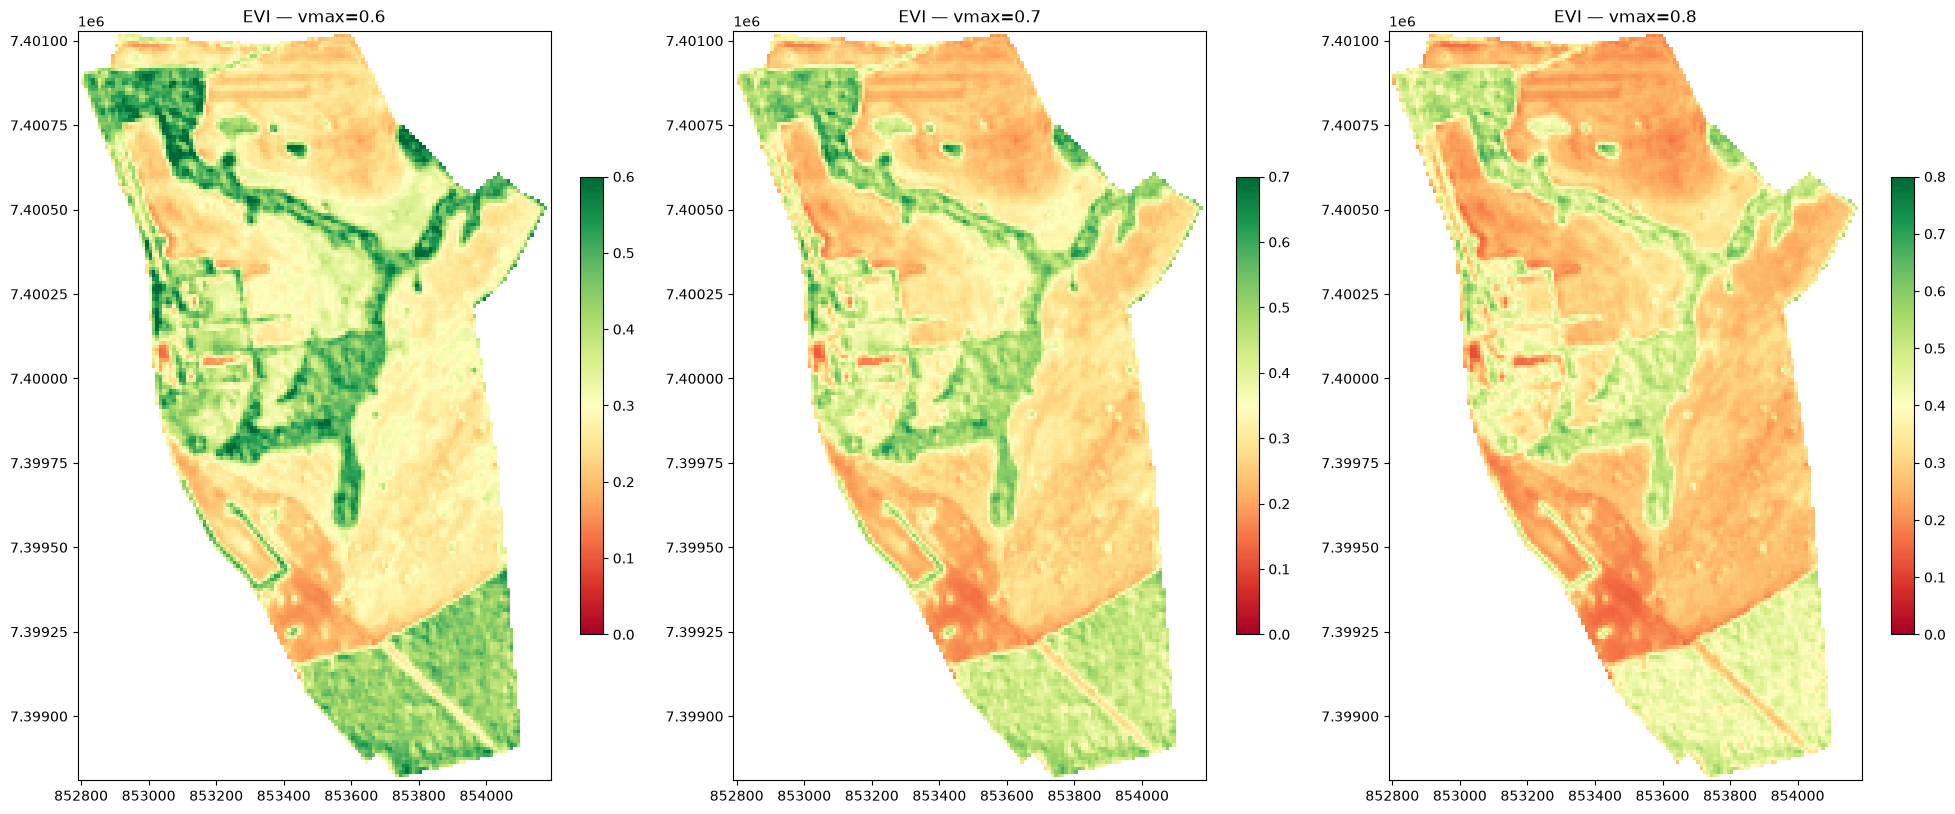

In [12]:
from pathlib import Path
import rioxarray
import numpy as np

BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
NDVI_DIR = BASE / "data" / "processed" / "indices" / "ndvi"
EVI_DIR  = BASE / "data" / "processed" / "indices" / "evi"

# Carregar
ndvi = rioxarray.open_rasterio(NDVI_DIR / "ndvi_mediana_2025.tif").squeeze()
evi  = rioxarray.open_rasterio(EVI_DIR  / "evi_mediana_2025.tif").squeeze()

print(f"NDVI: shape {ndvi.shape}, CRS {ndvi.rio.crs}")
print(f"EVI:  shape {evi.shape},  CRS {evi.rio.crs}")

# Realinhar se necessário
if ndvi.shape != evi.shape:
    evi = evi.rio.reproject_match(ndvi)
    print(f"EVI realinhado: {evi.shape}")

# Stats
ndvi_vals = ndvi.values[~np.isnan(ndvi.values)]
evi_vals  = evi.values[~np.isnan(evi.values)]

print(f"\n{'Métrica':<10} {'NDVI':<12} {'EVI':<12}")
print("=" * 36)
print(f"{'Min':<10} {ndvi_vals.min():<12.3f} {evi_vals.min():<12.3f}")
print(f"{'Max':<10} {ndvi_vals.max():<12.3f} {evi_vals.max():<12.3f}")
print(f"{'Média':<10} {ndvi_vals.mean():<12.3f} {evi_vals.mean():<12.3f}")
print(f"{'P95':<10} {np.percentile(ndvi_vals, 95):<12.3f} {np.percentile(evi_vals, 95):<12.3f}")

# Correlação
mask = ~np.isnan(ndvi.values) & ~np.isnan(evi.values)
corr = np.corrcoef(ndvi.values[mask], evi.values[mask])[0, 1]
print(f"\n📊 Correlação NDVI vs EVI: {corr:.3f}")

# Diagnóstico
if corr > 0.85:
    print("✅ Alta correlação — dados coerentes")
elif corr > 0.6:
    print("⚠️ Correlação moderada — verificar fórmula do EVI")
else:
    print("❌ Correlação baixa — EVI provavelmente está errado")

# Compare três escalas diferentes
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, vmax in zip(axes, [0.6, 0.7, 0.8]):
    im = ax.imshow(
        evi_aoi, cmap="RdYlGn",
        vmin=0, vmax=vmax,
        interpolation="nearest",
        extent=[left, right, bottom, top]
    )
    ax.set_title(f"EVI — vmax={vmax}")
    plt.colorbar(im, ax=ax, shrink=0.6)

plt.tight_layout()
plt.show()